In [2]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 58.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import random
from faker import Faker

fake = Faker()

rows = 10000

products = ["Laptop","Phone","Tablet","Printer","Monitor","Keyboard","Mouse","Chair","Desk","Router"]
categories = ["Technology","Furniture","Office Supplies"]
regions = ["North","South","East","West"]
segments = ["Consumer","Corporate","Home Office"]

data = []

for i in range(rows):

    sales = round(random.uniform(50, 2000),2)
    cost = round(sales * random.uniform(0.4,0.9),2)
    discount = random.choice([0,0.1,0.2,0.3,0.4])
    profit = round(sales - cost - (sales*discount),2)

    row = {
        "Order_ID": random.randint(10000,99999),
        "Order_Date": fake.date_between(start_date='-2y', end_date='today'),
        "Product": random.choice(products),
        "Category": random.choice(categories),
        "Region": random.choice(regions),
        "Customer_Segment": random.choice(segments),
        "Sales": sales,
        "Cost": cost,
        "Discount": discount,
        "Profit": profit,
        "Quantity": random.randint(1,10)
    }

    data.append(row)

df = pd.DataFrame(data)

# Introduce missing values
for col in ["Sales","Profit","Category"]:
    df.loc[df.sample(frac=0.05).index, col] = np.nan

# Introduce duplicates
df = pd.concat([df, df.sample(200)])

df.to_csv("raw_sales_dataset.csv", index=False)

print("Dataset created with", len(df), "rows")

Dataset created with 10200 rows


In [4]:
import pandas as pd

df = pd.read_csv("raw_sales_dataset.csv")

df.head()

,Order_ID,Order_Date,Product,Category,Region,Customer_Segment,Sales,Cost,Discount,Profit,Quantity
0,73871,2025-06-16,Monitor,Furniture,North,Consumer,1733.29,783.20,0.4,256.77,1
1,72211,2025-11-02,Chair,Office Supplies,West,Home Office,736.25,477.00,0.3,38.38,3
2,64242,2025-09-15,Printer,Furniture,North,Home Office,504.28,268.45,0.3,84.55,5
3,29379,2025-09-30,Chair,Furniture,East,Consumer,695.86,468.25,0.0,227.61,3
4,71728,2025-07-25,Chair,Furniture,North,Home Office,1756.68,1576.72,0.3,-347.04,6


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10200 non-null  int64  
 1   Order_Date        10200 non-null  object 
 2   Product           10200 non-null  object 
 3   Category          9693 non-null   object 
 4   Region            10200 non-null  object 
 5   Customer_Segment  10200 non-null  object 
 6   Sales             9689 non-null   float64
 7   Cost              10200 non-null  float64
 8   Discount          10200 non-null  float64
 9   Profit            9686 non-null   float64
 10  Quantity          10200 non-null  int64  
dtypes: float64(4), int64(2), object(5)
memory usage: 876.7+ KB


,Order_ID,Sales,Cost,Discount,Profit,Quantity
count,10200.000000,9689.000000,10200.000000,10200.000000,9686.000000,10200.000000
mean,54861.433431,1035.528348,671.959529,0.201441,156.648963,5.502255
std,25943.449170,561.063378,401.665080,0.141244,250.971459,2.888895
min,10003.000000,50.000000,21.190000,0.000000,-582.430000,1.000000
25%,32416.750000,557.390000,337.487500,0.100000,4.102500,3.000000
50%,55097.500000,1033.810000,641.595000,0.200000,104.155000,5.000000
75%,77236.250000,1523.510000,936.390000,0.300000,285.805000,8.000000
max,99996.000000,1999.950000,1781.950000,0.400000,1161.920000,10.000000


In [6]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Product,0
Category,507
Region,0
Customer_Segment,0
Sales,511
Cost,0
Discount,0
Profit,514


In [7]:
df.duplicated().sum()

np.int64(200)

In [8]:
df.dtypes

,0
Order_ID,int64
Order_Date,object
Product,object
Category,object
Region,object
Customer_Segment,object
Sales,float64
Cost,float64
Discount,float64
Profit,float64


In [9]:
df = df.drop_duplicates()

In [10]:
df["Sales"].fillna(df["Sales"].mean(), inplace=True)
df["Profit"].fillna(df["Profit"].mean(), inplace=True)
df["Category"].fillna("Unknown", inplace=True)

/tmp/ipykernel_323/1243914959.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Sales"].fillna(df["Sales"].mean(), inplace=True)
/tmp/ipykernel_323/1243914959.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [11]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [12]:
df["Profit_Margin"] = (df["Profit"] / df["Sales"]) * 100
df["Revenue_per_Item"] = df["Sales"] / df["Quantity"]
df["Month"] = df["Order_Date"].dt.month
df["Year"] = df["Order_Date"].dt.year

In [13]:
total_revenue = df["Sales"].sum()
print(total_revenue)

10351373.294736842


In [14]:
region_sales = df.groupby("Region")["Sales"].sum()
print(region_sales)

Region
East     2.482053e+06
North    2.579352e+06
South    2.642560e+06
West     2.647408e+06
Name: Sales, dtype: float64


In [15]:
category_profit = df.groupby("Category")["Profit"].sum()
print(category_profit)

Category
Furniture          490777.093895
Office Supplies    495656.996447
Technology         508994.748832
Unknown             67579.529247
Name: Profit, dtype: float64


In [16]:
monthly_sales = df.groupby("Month")["Sales"].sum()
print(monthly_sales)

Month
1     868177.125167
2     760052.259202
3     977971.158520
4     913760.671815
5     870108.113803
6     820260.890566
7     869556.137156
8     820772.177838
9     856086.878520
10    830687.524485
11    864121.695167
12    899818.662497
Name: Sales, dtype: float64


In [17]:
top_products = df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_products)

Product
Laptop      1.086498e+06
Chair       1.064177e+06
Keyboard    1.061768e+06
Phone       1.055361e+06
Tablet      1.031865e+06
Router      1.028569e+06
Desk        1.024837e+06
Printer     1.020886e+06
Monitor     1.003160e+06
Mouse       9.742512e+05
Name: Sales, dtype: float64


In [18]:
loss_products = df[df["Profit"] < 0]

loss_products.groupby("Product")["Profit"].sum()

,Profit
Product,
Chair,-27645.67
Desk,-28142.92
Keyboard,-28513.69
Laptop,-28035.20
Monitor,-25441.82
Mouse,-22388.97
Phone,-24827.71
Printer,-25666.39
Router,-25909.06


In [19]:
df.to_csv("cleaned_sales_data.csv", index=False)

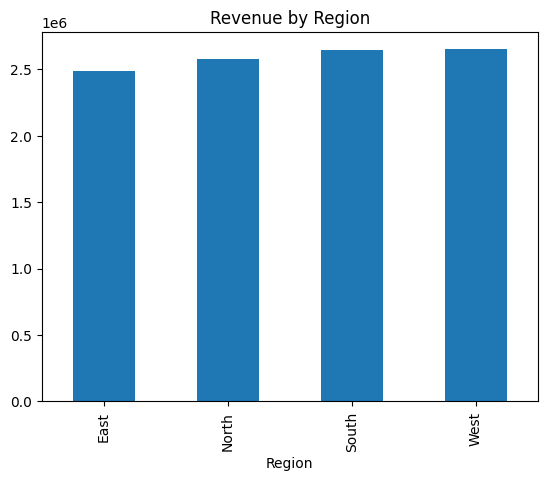

In [20]:
import matplotlib.pyplot as plt

region_sales.plot(kind="bar")

plt.title("Revenue by Region")

plt.show()

In [21]:
from google.colab import files
files.download("cleaned_sales_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>